In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

In [245]:
data_path = "full_dataset.csv"

# Load data

Now that we have extracted all our data and made preprocessing we are ready to start building a model. The first thing we wil do is so load the combined data and pick relevant features. As part of this we aggred to convert the topics into categorical features. By converting the hight probability value to 1. (Note : It's not actually a probability beacause we haven't normalized, but this doesn't matter)

In [246]:
########## ---------- Read data ---------- ########## 
df = pd.read_csv(data_path)
df.columns

Index(['post_date_x', 'post_count', 'n_image_only', 'avg_upvotes',
       'max_upvotes', 'total_upvotes', 'avg_reblogs', 'total_reblogs',
       'avg_replies', 'n_quotes', 'n_with_link', 'avg_text_len',
       'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
       'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
       'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
       'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
       'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
       'trump_sentiment_pct_negative', 'date', 'post_date_y',
       'news_sentiment_mean_y', 'news_sentiment_rolling', 'cpi',
       'interest_rate', 'consumer_sentiment', 'unemployment'],
      dtype='object')

In [247]:
# Make sure time is sorted
order = np.argsort(df["date"].values)
df = df.iloc[order]

In [248]:
########## ---------- Convert into categorical ---------- ########## 
topic_cols = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11'
]

# find max column per row
max_cols = df[topic_cols].idxmax(axis=1)

# zero everything
df[topic_cols] = 0

# set the max column to 1
for col in topic_cols:
    df.loc[max_cols == col, col] = 1

# Pick features

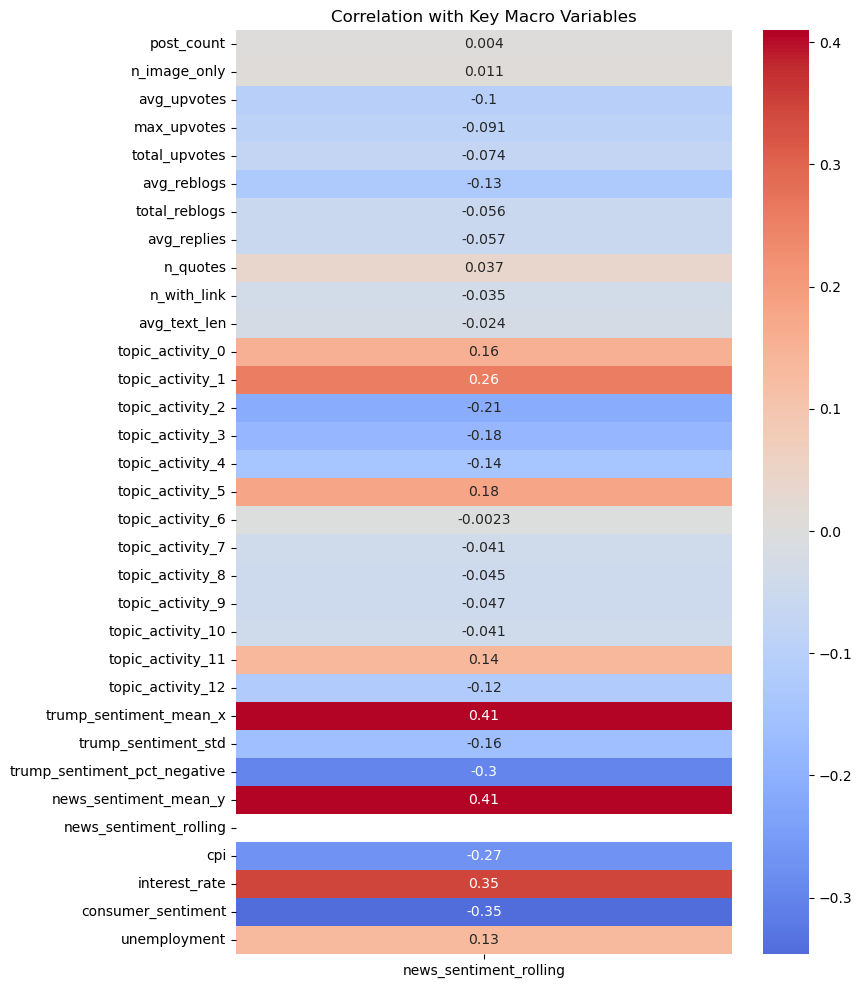

In [249]:
########## ---------- Correlation matrix ---------- ########## 
df_numeric = df.select_dtypes(include="number")
target_vars = ["news_sentiment_rolling"]
corr_matrix = df_numeric.corr()
corr_subset = corr_matrix[target_vars]
for var in target_vars:
    corr_subset.loc[var, var] = None

plt.figure(figsize=(8, 12))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with Key Macro Variables")
plt.show()

In [250]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
    'trump_sentiment_pct_negative', 
    'cpi', 
    'interest_rate', 
    'consumer_sentiment',
    'unemployment'
]

predictors = [
    'news_sentiment_rolling', 'news_sentiment_mean_y'
]

# Simple linear model

In [251]:
def train_model_ols(df, feature, target):
    
    # Define variables
    X = df[features].drop(columns=['topic_activity_0'])
    y = df[target]  

    # add intercept and fit
    X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop').fit()

    return model

def diagnose_model(model, time_data, alpha=0.05, lags=40, title=None):

    residuals = model.resid

    # --- feature stats ---
    coef = model.params.drop("const", errors="ignore")
    pvals = model.pvalues.drop("const", errors="ignore")
    significant = pvals < alpha

    # sort by absolute magnitude
    order = coef.abs().sort_values().index
    coef_sorted = coef.loc[order]
    significant_sorted = significant.loc[order]

    # --- predictions ---
    y_true = model.model.endog
    y_pred = model.fittedvalues

    # --- plotting ---
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # 1. ACF
    plot_acf(residuals, lags=lags, ax=axes[0])
    axes[0].set_title("ACF of Residuals")

    # 2. QQ plot
    sm.qqplot(residuals, line='s', ax=axes[1])
    axes[1].set_title("QQ Plot of Residuals")

    # 3. Feature contributions
    axes[2].barh(coef_sorted.index, coef_sorted.values)

    for i, (feature, value) in enumerate(coef_sorted.items()):
        if significant_sorted.loc[feature]:
            axes[2].text(
                value,
                i,
                "  *",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

    axes[2].axvline(0, linewidth=1)
    axes[2].set_title(f"Feature Contributions (p < {alpha})")
    axes[2].set_xlabel("Coefficient")

    # --- predictions ---
    y_true = model.model.endog
    y_pred = model.fittedvalues

    # align time index
    valid_idx = model.model.data.row_labels
    time_data = time_data.loc[valid_idx]

    # 4. Actual vs Predicted over time
    axes[3].scatter(time_data, y_true, alpha=0.5, label="Actual")
    axes[3].plot(time_data, y_pred, linewidth=2, label="Predicted")

    axes[3].set_title("Actual vs Predicted (Time)")
    axes[3].set_xlabel("Date")
    axes[3].set_ylabel("Value")
    axes[3].legend()
    axes[3].tick_params(axis='x', rotation=45)

    # --- global title ---
    if title is not None:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

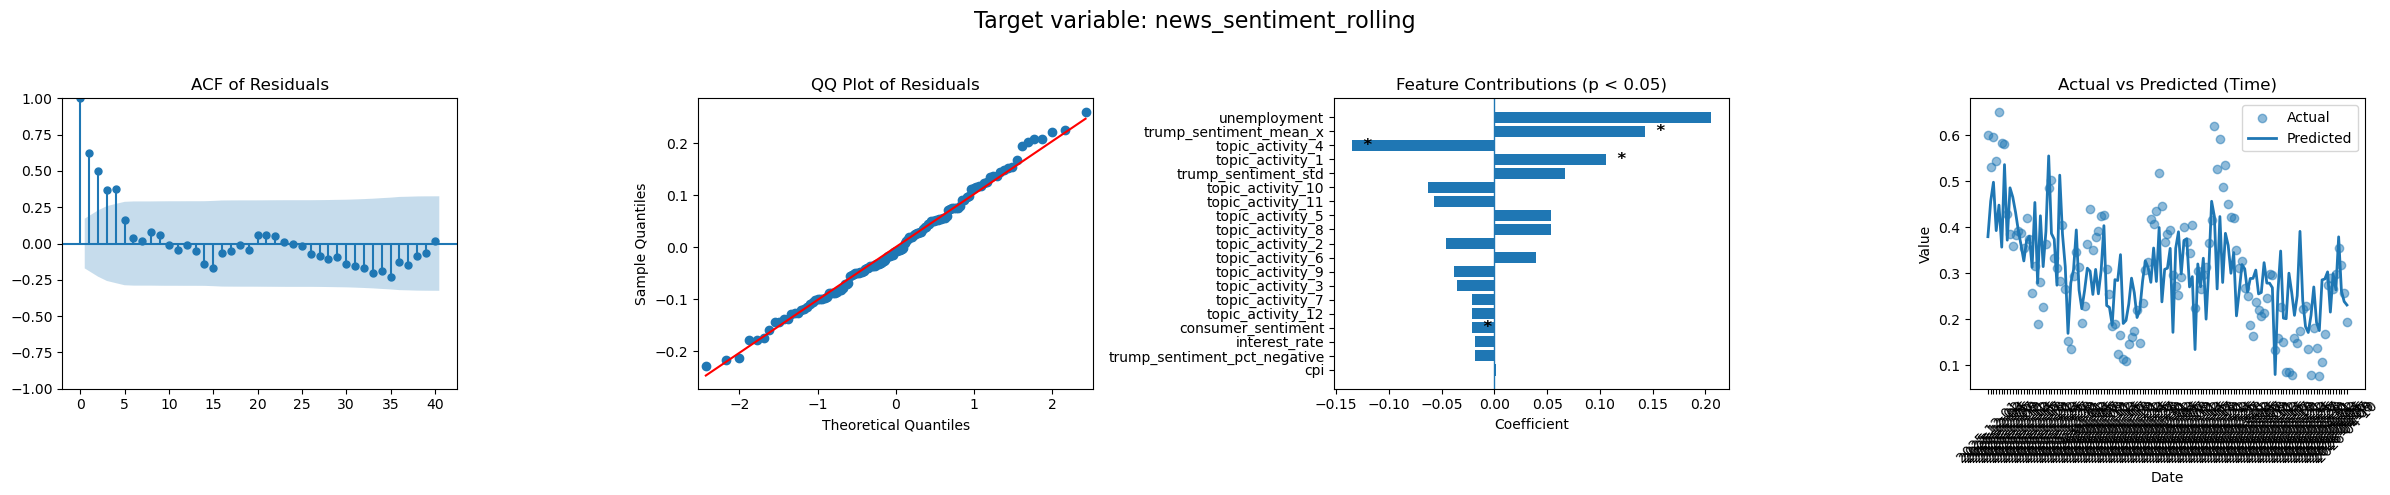

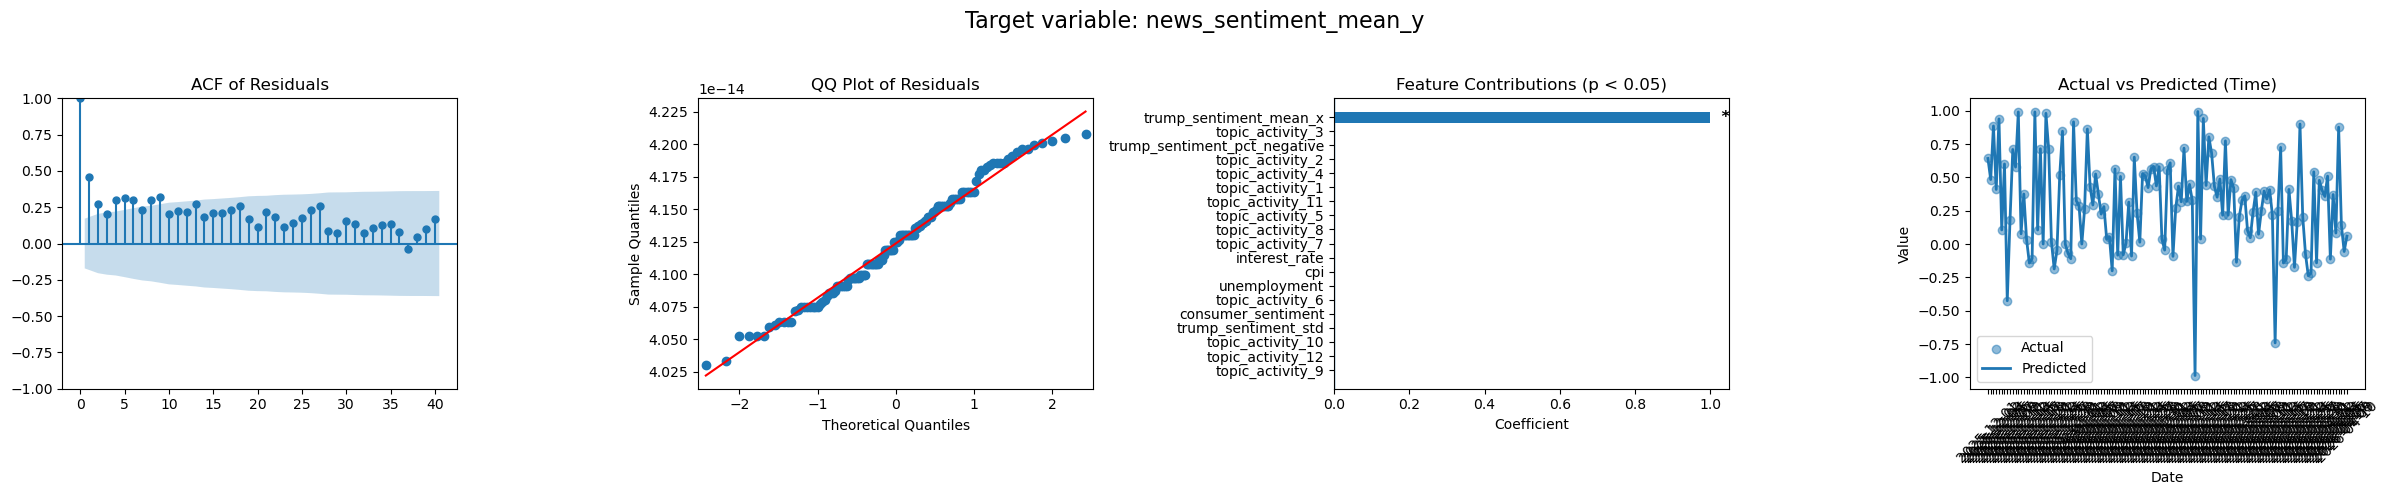

In [252]:
for i in range(len(predictors)): 
    model = train_model_ols(df, features, predictors[i])
    diagnose_model(model, time_data=df["date"], title=("Target variable: " + predictors[i]))